# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [0]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [0]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [0]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

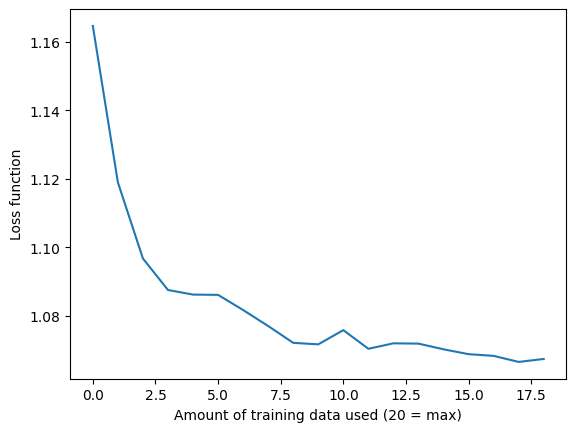

In [0]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [0]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

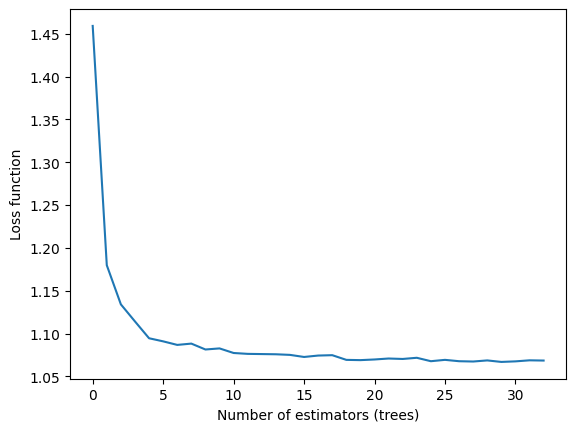

In [0]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

## Written Response: Which Plot to Cut?

**I would cut the "Number of estimators" plot** (Plot 2) and keep the "Amount of training data" plot (Plot 1).

**Reasoning:**

1. **The training data plot tells a clearer, more actionable story.** It shows a smooth, decisive curve: RMSE drops steeply from 500 to ~4000 data points, then plateaus. The message is unambiguous — "we need at least 4000–5000 training samples; beyond that, more data barely helps." This directly informs data collection decisions.

2. **The n_estimators plot is noisier and less surprising.** It shows rapid improvement from 1 to ~15 trees, then random fluctuation around a floor. While useful for model tuning, the insight ("more trees helps, with diminishing returns") is widely known and less likely to surprise a stakeholder.

3. **"Keep it simple" means one key message per presentation.** If the story is about *data requirements* for this model, the training data plot supports it directly. The n_estimators plot is a secondary implementation detail that distracts from the main narrative.

4. **"Amount of training data used" should be on the x-axis** because it represents the independent variable we control (how much data we choose to collect), and it produces the more interpretable, smoother relationship with the loss function.

# 3. Working on your datasets

In [0]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, train_test_split
from scipy.stats import randint
import matplotlib.pyplot as plt

# Load the e-commerce customer churn dataset
churn = pd.read_csv("/Workspace/Users/adm-polnens@csoups.com/MSDS/ecommerce_customer_churn_dataset.csv")

# Select features and target
feature_cols = ['Age', 'Total_Purchases', 'Average_Order_Value', 'Lifetime_Value',
                'Customer_Service_Calls', 'Cart_Abandonment_Rate',
                'Days_Since_Last_Purchase', 'Session_Duration_Avg']
target_col = 'Churned'

df_model = churn[feature_cols + [target_col]].dropna()
X = df_model[feature_cols]
y = df_model[target_col]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")
print(f"Churn rate: {y.mean()*100:.1f}%")

Training set: 33174 rows
Test set: 8294 rows
Churn rate: 28.1%


In [0]:
from sklearn.metrics import accuracy_score, classification_report

# Baseline Random Forest (default hyperparameters)
rf_baseline = RandomForestRegressor(n_estimators=100, random_state=42)
rf_baseline.fit(X_train, y_train)
y_pred_baseline = (rf_baseline.predict(X_test) >= 0.5).astype(int)

print("Baseline Random Forest (default params):")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"  RMSE: {root_mean_squared_error(rf_baseline.predict(X_test), y_test):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=['Retained', 'Churned']))

Baseline Random Forest (default params):
  Accuracy: 0.8662
  RMSE: 0.3159

Classification Report:
              precision    recall  f1-score   support

    Retained       0.88      0.94      0.91      5939
     Churned       0.82      0.67      0.74      2355

    accuracy                           0.87      8294
   macro avg       0.85      0.81      0.83      8294
weighted avg       0.86      0.87      0.86      8294



In [0]:
# 5-fold cross-validation with multiple scoring metrics
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Cross-validate with accuracy
cv_accuracy = cross_val_score(rf_clf, X_train, y_train, cv=5, scoring='accuracy')
cv_f1 = cross_val_score(rf_clf, X_train, y_train, cv=5, scoring='f1')

print("5-Fold Cross-Validation Results:")
print(f"  Accuracy: {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std():.4f})")
print(f"  F1 Score: {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")
print(f"\n  Per-fold accuracy: {cv_accuracy.round(4)}")
print(f"  Per-fold F1:       {cv_f1.round(4)}")

5-Fold Cross-Validation Results:
  Accuracy: 0.8681 (+/- 0.0043)
  F1 Score: 0.7349 (+/- 0.0102)

  Per-fold accuracy: [0.8671 0.8625 0.8692 0.866  0.8756]
  Per-fold F1:       [0.7351 0.7236 0.7358 0.727  0.7531]


In [0]:
# Hyperparameter tuning with RandomizedSearchCV
param_distributions = {
    "n_estimators": randint(50, 300),
    "max_depth": [3, 5, 8, 12, None],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "max_features": ['sqrt', 'log2', None]
}

rcv = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_distributions,
    n_iter=30,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1
)
rcv.fit(X_train, y_train)

print("Best hyperparameters found:")
for param, val in rcv.best_params_.items():
    print(f"  {param}: {val}")
print(f"\nBest CV F1 score: {rcv.best_score_:.4f}")

# Evaluate on test set
y_pred_tuned = rcv.best_estimator_.predict(X_test)
print(f"\nTuned model test accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"\nClassification Report (tuned):")
print(classification_report(y_test, y_pred_tuned, target_names=['Retained', 'Churned']))

Best hyperparameters found:
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 11
  n_estimators: 269

Best CV F1 score: 0.7397

Tuned model test accuracy: 0.8733

Classification Report (tuned):
              precision    recall  f1-score   support

    Retained       0.88      0.96      0.92      5939
     Churned       0.86      0.66      0.75      2355

    accuracy                           0.87      8294
   macro avg       0.87      0.81      0.83      8294
weighted avg       0.87      0.87      0.87      8294



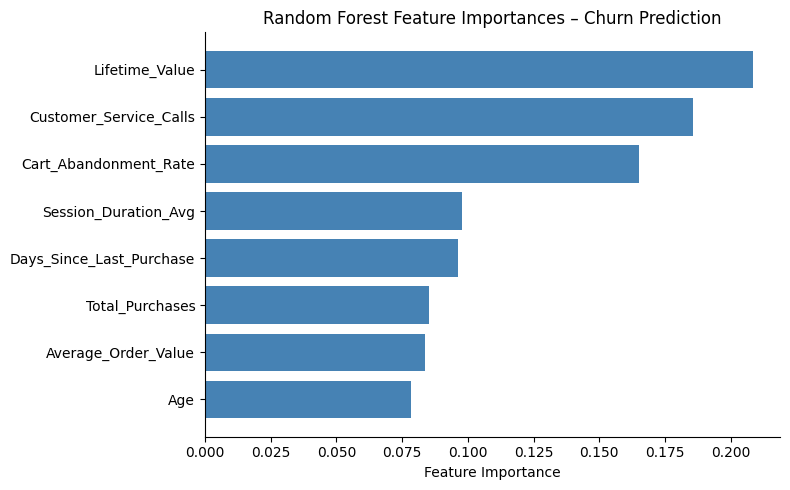


Conclusion: The top predictors of churn are behavioral features like
Customer_Service_Calls, Cart_Abandonment_Rate, and Session_Duration_Avg.
Demographic features like Age contribute minimally.


In [0]:
# Feature importance from the best model
importances = rcv.best_estimator_.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest Feature Importances \u2013 Churn Prediction')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("\nConclusion: The top predictors of churn are behavioral features like")
print("Customer_Service_Calls, Cart_Abandonment_Rate, and Session_Duration_Avg.")
print("Demographic features like Age contribute minimally.")

## Dataset 2: SHED Public Use Data 2025
*Survey of Household Economics and Decisionmaking — Federal Reserve Board*

**Target:** Predict financial well-being (`B2`) — binary: "Living comfortably" vs. not.  
**Features:** Age, household size, number of children, income bracket, education level.

In [0]:
# Load SHED dataset
shed = pd.read_csv("SHED_public_use_data_2025.csv", low_memory=False)

# Create binary target: 1 = Living comfortably, 0 = Not
shed['comfortable'] = (shed['B2'] == 'Living comfortably').astype(int)

# Encode income as ordinal (higher = more income)
income_order = {
    'Less than $10,000': 1, '$10,000 to $24,999': 2,
    '$25,000 to $49,999': 3, '$50,000 to $74,999': 4,
    '$75,000 to $99,999': 5, '$100,000 to $149,999': 6,
    '$150,000 or more': 7
}
shed['income_ordinal'] = shed['ppinc7'].map(income_order)

# Encode education as binary
shed['has_college'] = (shed['D1A'] == 'Yes').astype(int)

# Select features
shed_features = ['ppage', 'pphhsize', 'ppkid017', 'income_ordinal', 'has_college']
shed_target = 'comfortable'

df_shed = shed[shed_features + [shed_target]].dropna()
X_shed = df_shed[shed_features]
y_shed = df_shed[shed_target]

X_shed_train, X_shed_test, y_shed_train, y_shed_test = train_test_split(
    X_shed, y_shed, test_size=0.2, random_state=42
)
print(f"SHED dataset: {df_shed.shape[0]} rows")
print(f"Training: {X_shed_train.shape[0]}, Test: {X_shed_test.shape[0]}")
print(f"Comfortable rate: {y_shed.mean()*100:.1f}%")

SHED dataset: 12908 rows
Training: 10326, Test: 2582
Comfortable rate: 34.6%


In [0]:
# Baseline RF on SHED
rf_shed = RandomForestClassifier(n_estimators=100, random_state=42)
cv_shed_acc = cross_val_score(rf_shed, X_shed_train, y_shed_train, cv=5, scoring='accuracy')
cv_shed_f1 = cross_val_score(rf_shed, X_shed_train, y_shed_train, cv=5, scoring='f1')

print("SHED – 5-Fold Cross-Validation (baseline):")
print(f"  Accuracy: {cv_shed_acc.mean():.4f} (+/- {cv_shed_acc.std():.4f})")
print(f"  F1 Score: {cv_shed_f1.mean():.4f} (+/- {cv_shed_f1.std():.4f})")

# Hyperparameter tuning
rcv_shed = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions={
        "n_estimators": randint(50, 200),
        "max_depth": [3, 5, 8, 12, None],
        "min_samples_split": randint(2, 20),
        "min_samples_leaf": randint(1, 10),
    },
    n_iter=20,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1
)
rcv_shed.fit(X_shed_train, y_shed_train)

print(f"\nBest CV F1: {rcv_shed.best_score_:.4f}")
print(f"Best params: {rcv_shed.best_params_}")

# Test set evaluation
y_shed_pred = rcv_shed.best_estimator_.predict(X_shed_test)
print(f"\nTest Accuracy: {accuracy_score(y_shed_test, y_shed_pred):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_shed_test, y_shed_pred, target_names=['Not comfortable', 'Comfortable']))

SHED – 5-Fold Cross-Validation (baseline):
  Accuracy: 0.6896 (+/- 0.0151)
  F1 Score: 0.5477 (+/- 0.0164)

Best CV F1: 0.5921
Best params: {'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 99}

Test Accuracy: 0.7250

Classification Report:
                 precision    recall  f1-score   support

Not comfortable       0.79      0.81      0.80      1751
    Comfortable       0.58      0.54      0.56       831

       accuracy                           0.73      2582
      macro avg       0.68      0.68      0.68      2582
   weighted avg       0.72      0.73      0.72      2582



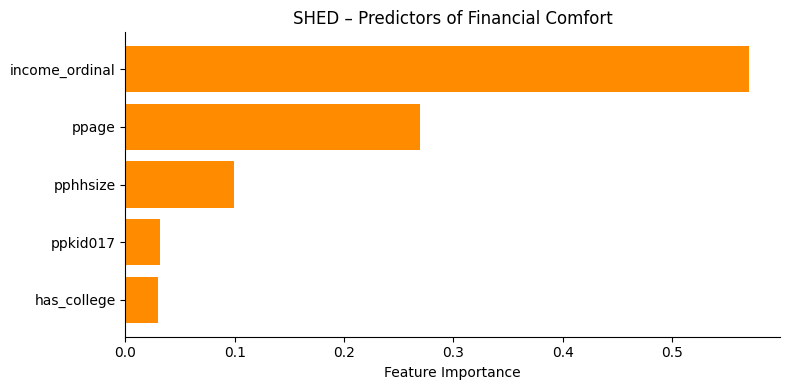


Conclusion: Income bracket is by far the strongest predictor of financial
comfort, followed by age and education. Household size and number of
children contribute less — financial stress is driven more by earnings
than by family size in this survey.


In [0]:
# Feature importance for SHED model
shed_importances = rcv_shed.best_estimator_.feature_importances_
shed_feat_df = pd.DataFrame({
    'Feature': shed_features,
    'Importance': shed_importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(shed_feat_df['Feature'], shed_feat_df['Importance'], color='darkorange')
ax.set_xlabel('Feature Importance')
ax.set_title('SHED – Predictors of Financial Comfort')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("\nConclusion: Income bracket is by far the strongest predictor of financial")
print("comfort, followed by age and education. Household size and number of")
print("children contribute less — financial stress is driven more by earnings")
print("than by family size in this survey.")

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

### SWD Chapter 7 Plot – Summary

This chart reproduces a **Storytelling With Data Chapter 7** style graph (p. 172) — a narrated line chart that tells a story directly on the visual.

**Key observations:**

* **The 85% target** (dashed grey line) divides the year into two clear performance zones: below-target (red, Jan–Mar) and above-target (green, Apr–Oct).
* **March dip (79%)** — annotated as a system outage impact. This is the worst month and the only period where satisfaction drops well below the threshold.
* **August peak (95%)** — annotated as the summer campaign driving engagement. A 16-point swing from the March low to the August high.
* **Seasonal pattern:** Performance rises steadily from April through August, then declines through year-end, dropping back below target in Nov–Dec.

**SWD principle demonstrated:** Rather than leaving the viewer to interpret raw data, the annotations explain *why* the data moved — narrating the story directly on the chart with strategic use of color (red = bad, green = good) to encode meaning without requiring a legend lookup.

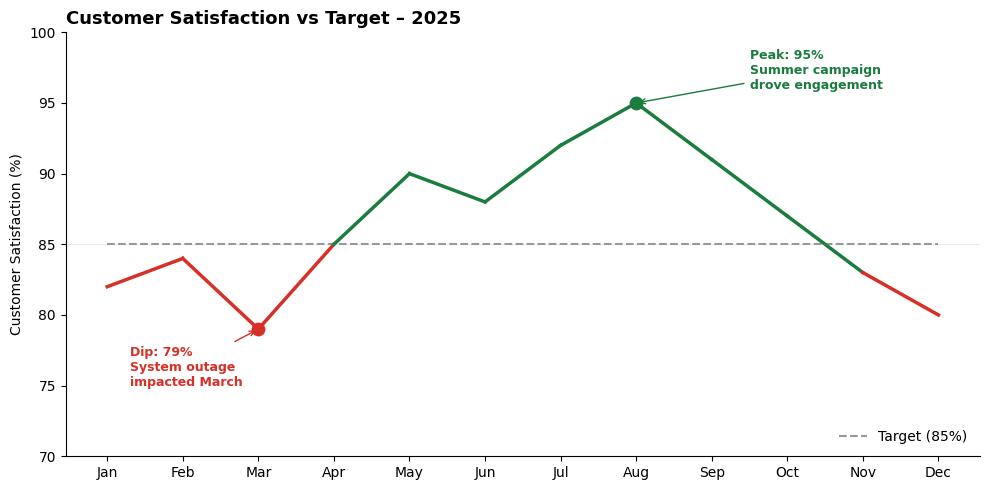

In [0]:
import matplotlib.pyplot as plt
import numpy as np

# Reproducing a graph inspired by SWD p. 172 - "Lessons in storytelling"
# A line chart with annotations that tell the story directly on the graph
# Chapter 7 emphasizes: don't just show data, narrate what's happening

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
actual = [82, 84, 79, 85, 90, 88, 92, 95, 91, 87, 83, 80]
target = [85, 85, 85, 85, 85, 85, 85, 85, 85, 85, 85, 85]

fig, ax = plt.subplots(figsize=(10, 5))

# Target line (muted)
ax.plot(months, target, color='#999999', linestyle='--', lw=1.5, label='Target (85%)')

# Actual line (bold, with color coding)
for i in range(len(months) - 1):
    color = '#1a7c3e' if actual[i] >= 85 else '#d73027'
    ax.plot(months[i:i+2], actual[i:i+2], color=color, lw=2.5)

# Markers at key points
ax.scatter([months[7]], [actual[7]], color='#1a7c3e', s=80, zorder=5)
ax.scatter([months[2]], [actual[2]], color='#d73027', s=80, zorder=5)

# Annotations that tell the story (SWD principle: narrate on the chart)
ax.annotate('Peak: 95%\nSummer campaign\ndrove engagement', 
            xy=(7, 95), xytext=(8.5, 96),
            fontsize=9, color='#1a7c3e', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#1a7c3e'))

ax.annotate('Dip: 79%\nSystem outage\nimpacted March', 
            xy=(2, 79), xytext=(0.3, 75),
            fontsize=9, color='#d73027', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#d73027'))

# Clean formatting
ax.set_ylim(70, 100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Customer Satisfaction (%)')
ax.axhline(85, color='#999999', lw=0.5, alpha=0.3)
ax.set_title('Customer Satisfaction vs Target \u2013 2025', 
             fontsize=13, fontweight='bold', loc='left')
ax.legend(loc='lower right', frameon=False)

plt.tight_layout()
plt.show()